In [1]:
import copy
import os
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import chardet
from datetime import datetime, timedelta
import multiprocessing
from multiprocessing import Pool
import shap
import fasttreeshap
import hnswlib
from sklearn.preprocessing import StandardScaler
from scipy.spatial import KDTree
from scipy.spatial import cKDTree

In [2]:


def extract_date_from_filename_sce(filename):
    base = os.path.basename(filename)
    
    date_str = base[-14:-4]  
    #print(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')


folder_path_sce = '/disk/r146/hcuiah/power/power/algorithm_sce_data'  

all_files_sce = [os.path.join(folder_path_sce, f) for f in os.listdir(folder_path_sce) if os.path.isfile(os.path.join(folder_path_sce, f))and f.endswith('.csv')]
file_count = len(all_files_sce)
#print(file_count)

all_files_sce_sorted = sorted(all_files_sce, key=extract_date_from_filename_sce)
all_data_frames = []
for f in all_files_sce_sorted:
    with open(f, 'rb') as file:
        result = chardet.detect(file.read())
    encoding = result['encoding']
    df = pd.read_csv(f, encoding=encoding, index_col=0)
    all_data_frames.append(df)



all_data_sce = pd.concat(all_data_frames, ignore_index=True)



#print(all_data_sce)
#print(all_data_sce.shape)
target_sce = 'Carbon_Emission'  
features_sce_with_annual = all_data_sce.drop(columns=[target_sce]) 
features_sce = features_sce_with_annual.drop(columns='Annual_Carbon_Emission')



print(features_sce)


          Population     Nightlight   Urban_Area
0       4.033910e+05   81477.624710  1464.000000
1       6.793804e+04    3116.328627   335.235294
2       1.706621e+05    5827.506667   483.000000
3       3.626392e+05   15066.899220  1169.070588
4       2.141485e+05    7475.276078   748.890196
...              ...            ...          ...
670865  6.063758e+06   54011.813330  1437.207843
670866  6.229375e+05   15800.616860   593.988235
670867  6.410638e+05  173115.041200  2599.890196
670868  3.918240e+05   10179.980780   842.058824
670869  1.624575e+05    6951.672549   387.627451

[670870 rows x 3 columns]


In [3]:


def extract_date_from_filename_clim(filename):
    base = os.path.basename(filename)
    
    date_str = base[-12:-4]  
    #print(date_str)
    return datetime.strptime(date_str,'%Y%m%d')



folder_path_clim = '/disk/r146/hcuiah/power/power/algorithm_clim_data'  


all_files_clim = [os.path.join(folder_path_clim, f) for f in os.listdir(folder_path_clim) if os.path.isfile(os.path.join(folder_path_clim, f))and f.endswith('.csv')]
all_files_clim_sorted = sorted(all_files_clim, key=extract_date_from_filename_clim)

all_data_frames_clim = []
for f in all_files_clim_sorted:
    with open(f, 'rb') as file:
        result = chardet.detect(file.read())
    encoding = result['encoding']
    df = pd.read_csv(f, encoding=encoding,index_col=0)
    all_data_frames_clim.append(df)



all_data_clim = pd.concat(all_data_frames_clim, ignore_index=True)


#print(all_data_clim)


print(all_data_clim)
#print(features_clim)

annual_carbon = 'Annual_Carbon_Emission'

clim_without_annual = all_data_clim.drop(columns=[annual_carbon]) 
print(clim_without_annual)


         Humidity   elevation   Rainfall  Temperature  WindSpeed  \
0       86.180485  101.693060   0.024163     7.969243   2.771731   
1       79.546844   31.984680   2.048448     5.540838   7.551524   
2       81.813309   63.334271   1.481431     5.864697   7.448873   
3       90.310109  291.570718   2.584970     4.028017   5.388154   
4       89.158973  521.101918   5.037054     2.222457   6.561753   
...           ...         ...        ...          ...        ...   
670865  64.675292    9.806961   0.000000    23.578328   2.201178   
670866  93.405815   24.488271   5.483107     3.223446   6.005229   
670867  79.252038  212.630181  12.465162     4.856947   3.844480   
670868  92.727482  342.278264   1.861010     1.317798   4.521045   
670869  90.501155    9.097688   4.014644     3.722865   5.885913   

        Annual_Carbon_Emission  Carbon_Emission  
0                    28.550740         1.818988  
1                   218.397000         0.316254  
2                    45.644301   

          Population     Nightlight   Urban_Area   Humidity   elevation  \
0       4.033910e+05   81477.624710  1464.000000  86.180485  101.693060   
1       6.793804e+04    3116.328627   335.235294  79.546844   31.984680   
2       1.706621e+05    5827.506667   483.000000  81.813309   63.334271   
3       3.626392e+05   15066.899220  1169.070588  90.310109  291.570718   
4       2.141485e+05    7475.276078   748.890196  89.158973  521.101918   
...              ...            ...          ...        ...         ...   
670865  6.063758e+06   54011.813330  1437.207843  64.675292    9.806961   
670866  6.229375e+05   15800.616860   593.988235  93.405815   24.488271   
670867  6.410638e+05  173115.041200  2599.890196  79.252038  212.630181   
670868  3.918240e+05   10179.980780   842.058824  92.727482  342.278264   
670869  1.624575e+05    6951.672549   387.627451  90.501155    9.097688   

         Rainfall  Temperature  WindSpeed  Carbon_Emission  
0        0.024163     7.969243   2.771

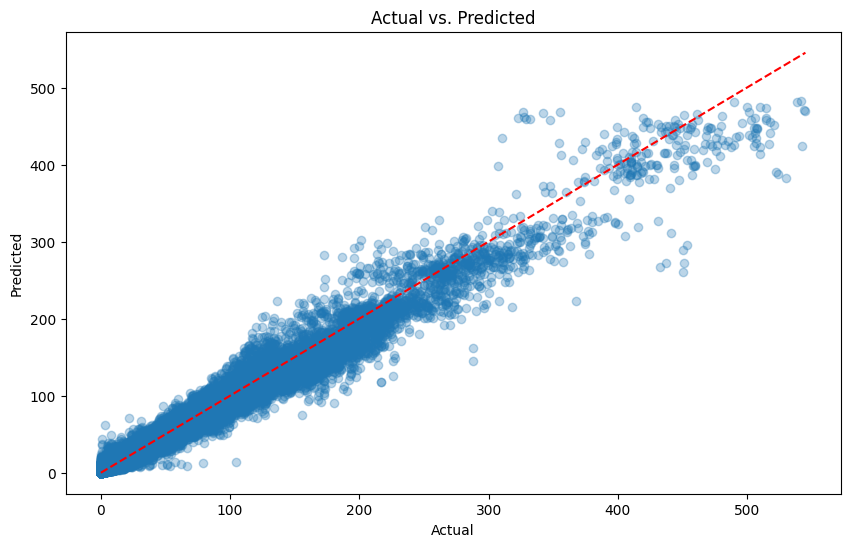

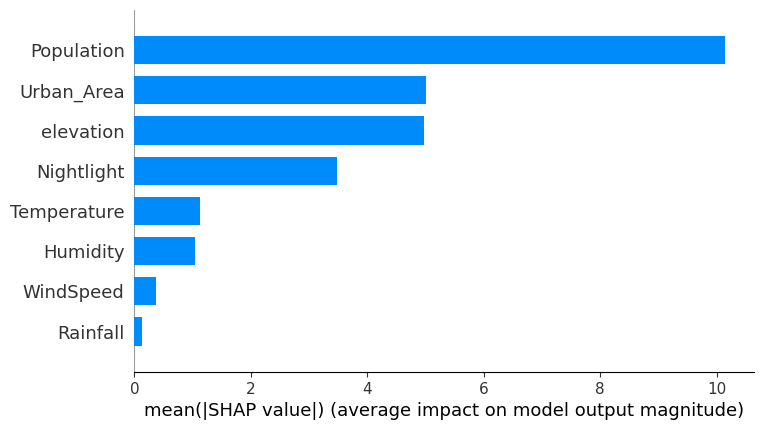

In [4]:


all_data = pd.concat([features_sce, clim_without_annual], axis=1)
print(all_data)
target = 'Carbon_Emission'

features = all_data.drop(columns=[target]) 
print(features)

X_train, X_test, y_train, y_test = train_test_split(features, all_data[target], test_size=0.3, random_state=42)

rf = RandomForestRegressor(random_state=42, n_jobs=90)

param_dist = {
    'n_estimators': sp_randint(100, 1000),
    'max_features': [None, 'sqrt', 'log2'],  
    'max_depth': sp_randint(3, 20), 
    'min_samples_split': sp_randint(2, 11),  
    'min_samples_leaf': sp_randint(1, 11),  
}


n_iter_search = 10  
random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=n_iter_search, cv=5, n_jobs=90)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_

rf_best = RandomForestRegressor(**best_params, random_state=42, n_jobs=90)


rf_best.fit(X_train, y_train)


y_pred_train = rf_best.predict(X_train)


mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f'Mean Squared Error trainset: {mse_train}')
print(f'Mean Absolute Error trainset: {mae_train}')
print(f'R2 Score trainset: {r2_train}')



y_pred = rf_best.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error testset: {mse}')
print(f'Mean Absolute Error testset: {mae}')
print(f'R2 Score testset: {r2}')



plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.show()

explainer = fasttreeshap.TreeExplainer(rf_best, algorithm='auto', n_jobs = -1)

#explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

fasttreeshap.summary_plot(shap_values, X_test, plot_type="bar")

In [5]:
np.save('/localdisk/r146/export/hcuiah/power/power/shap_values_power/shap_values_power', shap_values)

In [6]:


shap_values= np.load('/disk/r146/hcuiah/power/power/shap_values_power/shap_values_power.npy', allow_pickle=True)

all_data = pd.concat([features_sce, clim_without_annual], axis=1)
#print(all_data)
target = 'Carbon_Emission'

features = all_data.drop(columns=[target]) 
#print(features)

X_train, X_test, y_train, y_test = train_test_split(features, all_data[target], test_size=0.3, random_state=42)



In [7]:

shap_abs_mean = np.abs(shap_values).mean(axis=0)
print(shap_abs_mean)

norm_shap_abs_mean = shap_abs_mean / shap_abs_mean.sum()
print(norm_shap_abs_mean)


shap_importance = pd.DataFrame(norm_shap_abs_mean, index=X_test.columns, columns=['SHAP Importance'])


shap_importance_sorted = shap_importance.sort_values(by='SHAP Importance', ascending=False)

print(shap_importance_sorted)

[10.1412368   3.47587667  5.01399163  1.04130817  4.97291242  0.12530769
  1.12949948  0.36835717]
[0.3860609  0.13232114 0.19087476 0.03964096 0.18931094 0.00477027
 0.04299826 0.01402278]
             SHAP Importance
Population          0.386061
Urban_Area          0.190875
elevation           0.189311
Nightlight          0.132321
Temperature         0.042998
Humidity            0.039641
WindSpeed           0.014023
Rainfall            0.004770


In [8]:
all_data = pd.concat([features_sce, clim_without_annual], axis=1)
print(all_data)
target = 'Carbon_Emission'

features = all_data.drop(columns=[target]) 
print(features)

          Population     Nightlight   Urban_Area   Humidity   elevation  \
0       4.033910e+05   81477.624710  1464.000000  86.180485  101.693060   
1       6.793804e+04    3116.328627   335.235294  79.546844   31.984680   
2       1.706621e+05    5827.506667   483.000000  81.813309   63.334271   
3       3.626392e+05   15066.899220  1169.070588  90.310109  291.570718   
4       2.141485e+05    7475.276078   748.890196  89.158973  521.101918   
...              ...            ...          ...        ...         ...   
670865  6.063758e+06   54011.813330  1437.207843  64.675292    9.806961   
670866  6.229375e+05   15800.616860   593.988235  93.405815   24.488271   
670867  6.410638e+05  173115.041200  2599.890196  79.252038  212.630181   
670868  3.918240e+05   10179.980780   842.058824  92.727482  342.278264   
670869  1.624575e+05    6951.672549   387.627451  90.501155    9.097688   

         Rainfall  Temperature  WindSpeed  Carbon_Emission  
0        0.024163     7.969243   2.771

In [9]:
importance = norm_shap_abs_mean
print(importance)

[0.3860609  0.13232114 0.19087476 0.03964096 0.18931094 0.00477027
 0.04299826 0.01402278]


In [10]:


scaler = StandardScaler()


features_norm = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)


features_mean_values = scaler.mean_
features_std_values = scaler.scale_

print(features_mean_values)
print(features_std_values)

print(features_norm)

[2.51756563e+06 9.63641288e+04 2.26627748e+03 6.84258355e+01
 3.86815316e+02 2.91026152e+00 1.44493586e+01 3.10422185e+00]
[4.03601092e+06 1.29237709e+05 2.98075658e+03 1.58374892e+01
 5.43085697e+02 6.92066445e+00 1.00301748e+01 1.42531531e+00]
        Population  Nightlight  Urban_Area  Humidity  elevation  Rainfall  \
0        -0.523828   -0.115187   -0.269152  1.121052  -0.525004 -0.417026   
1        -0.606943   -0.721522   -0.647836  0.702195  -0.653360 -0.124528   
2        -0.581491   -0.700543   -0.598263  0.845303  -0.595635 -0.206459   
3        -0.533925   -0.629052   -0.368097  1.381802  -0.175377 -0.047003   
4        -0.570716   -0.687793   -0.509061  1.309118   0.247266  0.307310   
...            ...         ...         ...       ...        ...       ...   
670865    0.878638   -0.327709   -0.278141 -0.236814  -0.694197 -0.420518   
670866   -0.469431   -0.623375   -0.561028  1.577269  -0.667164  0.371763   
670867   -0.464940    0.593874    0.111922  0.683581  -0.3207

In [11]:



features_norm_weight = features_norm.multiply(importance, axis=1)
print(features_norm_weight)

        Population  Nightlight  Urban_Area  Humidity  elevation  Rainfall  \
0        -0.202229   -0.015242   -0.051374  0.044440  -0.099389 -0.001989   
1        -0.234317   -0.095473   -0.123656  0.027836  -0.123688 -0.000594   
2        -0.224491   -0.092697   -0.114193  0.033509  -0.112760 -0.000985   
3        -0.206127   -0.083237   -0.070260  0.054776  -0.033201 -0.000224   
4        -0.220331   -0.091010   -0.097167  0.051895   0.046810  0.001466   
...            ...         ...         ...       ...        ...       ...   
670865    0.339208   -0.043363   -0.053090 -0.009388  -0.131419 -0.002006   
670866   -0.181229   -0.082486   -0.107086  0.062524  -0.126301  0.001773   
670867   -0.179495    0.078582    0.021363  0.027098  -0.060718  0.006586   
670868   -0.203336   -0.088240   -0.091201  0.060827  -0.015525 -0.000723   
670869   -0.225276   -0.091546   -0.120301  0.055254  -0.131666  0.000761   

        Temperature  WindSpeed  
0         -0.027780  -0.003271  
1        

In [12]:
features_norm_weight_with_carbon = features_norm_weight.copy()
features_norm_weight_with_carbon['Carbon_Emission'] = all_data['Carbon_Emission']
print(features_norm_weight_with_carbon)

        Population  Nightlight  Urban_Area  Humidity  elevation  Rainfall  \
0        -0.202229   -0.015242   -0.051374  0.044440  -0.099389 -0.001989   
1        -0.234317   -0.095473   -0.123656  0.027836  -0.123688 -0.000594   
2        -0.224491   -0.092697   -0.114193  0.033509  -0.112760 -0.000985   
3        -0.206127   -0.083237   -0.070260  0.054776  -0.033201 -0.000224   
4        -0.220331   -0.091010   -0.097167  0.051895   0.046810  0.001466   
...            ...         ...         ...       ...        ...       ...   
670865    0.339208   -0.043363   -0.053090 -0.009388  -0.131419 -0.002006   
670866   -0.181229   -0.082486   -0.107086  0.062524  -0.126301  0.001773   
670867   -0.179495    0.078582    0.021363  0.027098  -0.060718  0.006586   
670868   -0.203336   -0.088240   -0.091201  0.060827  -0.015525 -0.000723   
670869   -0.225276   -0.091546   -0.120301  0.055254  -0.131666  0.000761   

        Temperature  WindSpeed  Carbon_Emission  
0         -0.027780  -0.0

In [13]:



annual_carbon_emission = all_data_clim['Annual_Carbon_Emission'].values.reshape(-1, 1)


carbon_scaler = StandardScaler()
normalized_annual_carbon_emission = carbon_scaler.fit_transform(annual_carbon_emission)

annual_carbon_mean_values = carbon_scaler.mean_
annual_carbon_std_values = carbon_scaler.scale_



print(normalized_annual_carbon_emission)

annual_carbon_kdtree = cKDTree(normalized_annual_carbon_emission)



[[-0.49803256]
 [-0.48263924]
 [-0.49664656]
 ...
 [-0.36982112]
 [-0.50011997]
 [-0.13765569]]


In [14]:
def normalize_and_weight(city_attributes, mean_values, std_values, weights):
    
    

    normalized = (city_attributes - mean_values) / std_values

    weighted = normalized * weights
    return weighted


def normalized_annual_carbon(wait_to_cal_annual_carbon, mean_values, std_values):    
    return (wait_to_cal_annual_carbon-mean_values)/std_values

In [15]:
wait_to_cal_city_list = pd.read_csv('/disk/r146/hcuiah/power/power/wait_to_cal_city_list_final.csv')
print(wait_to_cal_city_list)

       FID
0     8192
1     8193
2     8198
3     8199
4     8200
...    ...
2638  8177
2639  8183
2640  8184
2641  8187
2642  8190

[2643 rows x 1 columns]


In [16]:



def gaussian_kernel(distance):
    c = 0.56
    average_distance = np.mean(distance)
    bandwidth = c*average_distance
    #bandwidth = silverman_bandwidth(distance)
    #bandwidth = scotts_rule_bandwidth(distance)
    #print(bandwidth)

    weights = np.exp(-0.5 * (distance**2) / bandwidth**2)
    return weights


        
        
#    return weights


def normalize_weights(weights):
    return weights / np.sum(weights)



In [21]:


start_date = datetime(2014, 3, 1)
end_date = datetime(2014, 5, 1)
n1 = 2920
n2 = 10
output_folder = "/localdisk/r146/export/hcuiah/power/power/new_carbon_output"
for single_date in pd.date_range(start_date, end_date):
    results = []
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/localdisk/r146/export/hcuiah/power/power/wait_to_cal_data_sce_with_long_term_carbon/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/localdisk/r146/export/hcuiah/power/power/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    
    
    
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        if fid != 7268:
            continue

        wait_to_cal_annual_carbon = row['8_Year_Avg_Carbon_Emission']
        print(wait_to_cal_annual_carbon)
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        #print(wait_to_cal_annual_carbon_after_deal)

        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        #print(dists)
        #print(idxs)

        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        

        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim)  
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        
 
        #print(row)
        city_attributes = row.drop(['8_Year_Avg_Carbon_Emission','Annual_Carbon_Emission']).to_numpy()
        print(city_attributes)
        
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        
   
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances:  

            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)

            filtered_labels = labels[:, 1:] 
            filtered_distances = distances[:, 1:] 
        else:

            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        print(filtered_distances)

        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)

        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        

        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)
        print(estimated_carbon_emission)
        results.append([fid, estimated_carbon_emission])
        break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)
    break

957.2798111175782
Population                    64433.558130
Nightlight                    15251.080000
Urban_Area                       63.000000
8_Year_Avg_Carbon_Emission      957.279811
Humidity                         71.255576
elevation                       268.628338
Rainfall                          4.119026
Temperature                     -13.056560
WindSpeed                         3.046105
Annual_Carbon_Emission          802.957000
Name: 2297, dtype: float64
[ 6.44335581e+04  1.52510800e+04  6.30000000e+01  7.12555764e+01
  2.68628338e+02  4.11902608e+00 -1.30565600e+01  3.04610524e+00]
[[0.00200043 0.00233006 0.00238663 0.00239099 0.00246227 0.00254536
  0.00260027 0.00260162 0.0026404  0.00271579]]
4.673922343983642


In [15]:
start_date = datetime(2012, 1, 19)
end_date = datetime(2020, 12, 30)
n1 = 20
n2 = 10
output_folder = "/localdisk/r146/export/hcuiah/power/power/output_carbon_power6"


def process_single_date(single_date):
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/localdisk/r146/export/hcuiah/power/power/wait_to_cal_data_sce/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/localdisk/r146/export/hcuiah/power/power/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    #print(data_combined)
    results = []
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        

        wait_to_cal_annual_carbon = row['Annual_Carbon_Emission']
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        

        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        average_filtered_distance = np.mean(dists)

        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        

        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim) 
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        

        
        city_attributes = row.drop('Annual_Carbon_Emission').to_numpy()
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        

        
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances: 

            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)

            filtered_labels = labels[:, 1:] 
            filtered_distances = distances[:, 1:] 
        else:

            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        #print(filtered_distances)

        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)
 
        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        

        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)

        results.append([fid, estimated_carbon_emission,average_filtered_distance])
        #break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission', 'Average_edgar_Distance'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)
        
    
date_range = pd.date_range(start_date, end_date)


with Pool(processes=120) as pool:  
    pool.map(process_single_date, date_range)

In [17]:
start_date = datetime(2012, 1, 19)
end_date = datetime(2020, 12, 30)
n1 = 730
n2 = 80
output_folder = "/localdisk/r146/export/hcuiah/power/power/final_carbon_output_n1_730_n2_80"


def process_single_date(single_date):
    date_str = single_date.strftime("%Y_%m_%d")
    file_path_sce = f"/disk/r146/hcuiah/power/power/wait_to_cal_data_sce_with_long_term_carbon/sce_6000_data_final{date_str}.csv"
    file_path_clim = f"/disk/r146/hcuiah/power/power/wait_to_cal_data_clim/clim_6000_data_final{single_date.strftime('%Y%m%d')}.csv"
    data_sce = pd.read_csv(file_path_sce).drop(columns=['FID','Annual_Carbon_Emission'])
    data_clim = pd.read_csv(file_path_clim).drop(columns=['FID'])
    data_combined = pd.concat([data_sce, data_clim], axis=1)
    #print(data_combined)
    results = []
    for index, row in data_combined.iterrows():
        fid = wait_to_cal_city_list.iloc[index]['FID']
        

        wait_to_cal_annual_carbon = row['8_Year_Avg_Carbon_Emission']
        wait_to_cal_annual_carbon_after_deal = normalized_annual_carbon(wait_to_cal_annual_carbon,annual_carbon_mean_values,annual_carbon_std_values)
        

        
        dists, idxs = annual_carbon_kdtree.query([wait_to_cal_annual_carbon_after_deal], k=n1)
        

        wait_to_cal_city_features_with_carbon = features_norm_weight_with_carbon.iloc[idxs[0]]
        wait_to_cal_city_features = features_norm_weight.iloc[idxs[0]].to_numpy()
        

        dim = wait_to_cal_city_features.shape[1]
        num_features = wait_to_cal_city_features.shape[0]
        p = hnswlib.Index(space='l2', dim=dim) 
        p.init_index(max_elements=num_features, ef_construction=200, M=16)
        p.add_items(wait_to_cal_city_features)
        p.set_ef(50)
        

        city_attributes = row.drop(['8_Year_Avg_Carbon_Emission','Annual_Carbon_Emission']).to_numpy()
        
        wait_to_cal_city_after_deal = normalize_and_weight(city_attributes,features_mean_values, features_std_values, importance)
        

        
        labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2)
        
        if 0 in distances:

            labels, distances = p.knn_query(wait_to_cal_city_after_deal, k=n2 + 1)

            filtered_labels = labels[:, 1:] 
            filtered_distances = distances[:, 1:] 
        else:

            filtered_labels = labels
            filtered_distances = distances
        
        #print(filtered_labels)
        #print(filtered_distances)

        carbon_weights = gaussian_kernel(filtered_distances)
        #print(carbon_weights)
        normalized_carbon_weights = normalize_weights(carbon_weights)
        normalized_carbon_weights = normalized_carbon_weights.flatten()
        #print(normalized_carbon_weights)

        similar_cities_carbon =  wait_to_cal_city_features_with_carbon['Carbon_Emission'].iloc[filtered_labels.flatten()].to_numpy()
        #print(similar_cities_carbon)
        

        estimated_carbon_emission = np.dot(normalized_carbon_weights, similar_cities_carbon)

        results.append([fid, estimated_carbon_emission])
        #break
    results_df = pd.DataFrame(results, columns=['FID', 'Estimated_Carbon_Emission'])
    output_csv_path = os.path.join(output_folder, f"carbon_emissions_{date_str}.csv")
    results_df.to_csv(output_csv_path, index=False)
        
    
date_range = pd.date_range(start_date, end_date)


with Pool(processes=120) as pool:  
    pool.map(process_single_date, date_range)

In [19]:
from scipy.stats import pearsonr

def extract_date_from_filename(filename):
    base = os.path.basename(filename)
    date_str = base[-14:-4] 
    return datetime.strptime(date_str, '%Y_%m_%d')

def read_and_merge_daily_data(real_emissions_folder, predicted_emissions_folder, start_date, end_date):
    date_range = pd.date_range(start_date, end_date)
    all_data_frames = []
    
    for single_date in date_range:
        date_str = single_date.strftime('%Y_%m_%d')
        real_emissions_file = os.path.join(real_emissions_folder, f'sce_power_data_final{date_str}.csv')
        predicted_emissions_file = os.path.join(predicted_emissions_folder, f'carbon_emissions_{date_str}.csv')
        
        if os.path.exists(real_emissions_file) and os.path.exists(predicted_emissions_file):
            real_emissions_df = pd.read_csv(real_emissions_file)
            predicted_emissions_df = pd.read_csv(predicted_emissions_file)

            predicted_emissions_df.rename(columns={'Estimated_Carbon_Emission': 'Carbon_Emission'}, inplace=True)

            merged_df = pd.merge(real_emissions_df, predicted_emissions_df[['FID', 'Carbon_Emission']], on='FID', suffixes=('_real', '_predicted'))
            all_data_frames.append(merged_df)
    

    all_data_combined = pd.concat(all_data_frames, ignore_index=True)
    #print(all_data_combined)
    return all_data_combined

def calculate_metrics(all_data_combined):
    mse = mean_squared_error(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    r2 = r2_score(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    n = all_data_combined.shape[0]
    rss = mse * n
    

    k = 2 
    aic = n * np.log(rss / n) + 2 * k
    pcc, _ = pearsonr(all_data_combined['Carbon_Emission_real'], all_data_combined['Carbon_Emission_predicted'])
    return mse, rmse, mae, r2, rss, aic,pcc


start_date = datetime(2019, 1, 1)
end_date = datetime(2020, 12, 30)


real_emissions_folder = '/disk/r146/hcuiah/power/power/algorithm_sce_data'
predicted_emissions_folder = '/localdisk/r146/export/hcuiah/power/power_final_data/final_carbon_power_20240801'


all_data_combined = read_and_merge_daily_data(real_emissions_folder, predicted_emissions_folder, start_date, end_date)
mse, rmse, mae, r2, rss, aic,pcc = calculate_metrics(all_data_combined)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
#print(f"R^2: {r2}")
print(f"RSS: {rss}")
print(f"AIC: {aic}")
print(f"PCC: {pcc}")
print(f"R^2: {np.square(pcc)}")

MSE: 620.0005910791114
RMSE: 24.899811065128816
MAE: 10.486619767436466
RSS: 383805165.9016131
AIC: 3980258.135848958
PCC: 0.7626580433759986
R^2: 0.5816472911261066


In [18]:


def extract_date_from_filename_sce(filename):
    base = os.path.basename(filename)
    
    date_str = base[-14:-4]  
    #print(date_str)
    return datetime.strptime(date_str, '%Y_%m_%d')


folder_path_sce = '/localdisk/r148/export/hcuiah/residential/algorithm_sce_data'  


all_files_sce = [os.path.join(folder_path_sce, f) for f in os.listdir(folder_path_sce) if os.path.isfile(os.path.join(folder_path_sce, f))and f.endswith('.csv')]
file_count = len(all_files_sce)
#print(file_count)

all_files_sce_sorted = sorted(all_files_sce, key=extract_date_from_filename_sce)
all_data_frames = []
for f in all_files_sce_sorted:
    with open(f, 'rb') as file:
        result = chardet.detect(file.read())
    encoding = result['encoding']
    df = pd.read_csv(f, encoding=encoding)
    df['source_file'] = os.path.basename(f)
    all_data_frames.append(df)



all_data_sce = pd.concat(all_data_frames, ignore_index=True)



rows_of_interest = idxs.flatten()
selected_rows = all_data_sce.iloc[rows_of_interest]
selected_rows = all_data_sce.iloc[rows_of_interest]

print(selected_rows[['FID', 'source_file']])



          FID                               source_file
54864   10455  sce_residential_data_final2019_02_20.csv
51582   10455  sce_residential_data_final2019_02_17.csv
228810  10455  sce_residential_data_final2019_07_29.csv
163170  10455  sce_residential_data_final2019_05_30.csv
366654  10455  sce_residential_data_final2019_12_02.csv
306484  10455  sce_residential_data_final2019_10_08.csv
87684   10455  sce_residential_data_final2019_03_22.csv
27514   10455  sce_residential_data_final2019_01_26.csv
270382  10455  sce_residential_data_final2019_09_05.csv
215682  10455  sce_residential_data_final2019_07_17.csv
294450  10455  sce_residential_data_final2019_09_27.csv
140196  10455  sce_residential_data_final2019_05_09.csv
50488   10455  sce_residential_data_final2019_02_16.csv
52676   10455  sce_residential_data_final2019_02_18.csv
262724  10455  sce_residential_data_final2019_08_29.csv
35172   10455  sce_residential_data_final2019_02_02.csv
104094  10455  sce_residential_data_final2019_04